# Customer Support RAG-Powered Intelligent Chatbot
### DEPI Final Project — Project 5
**Dataset:** CFPB Consumer Complaint Database

This notebook contains the full, cleaned pipeline for both milestones:

- **Milestone 1 — Data Collection & Preprocessing:** ingestion, cleaning, `rag_document` creation, EDA, processed corpus export.
- **Milestone 2 — RAG Pipeline:** full-dataset Chroma vector store (batched), Gemini-based RAG chain, generation-quality evaluation (BLEU/ROUGE), retrieval-quality evaluation (Recall@K, MRR), and optimization experiments (k, prompt engineering, embedding model, chunk size, retrieval strategy).

> ⚠️ Before running: upload your full CSV to Google Drive and confirm `CSV_PATH` in the config cell below. Add your `GOOGLE_API_KEY` to Colab Secrets before Milestone 2.

# 📁 Milestone 1 — Data Collection & Preprocessing

## 0. Setup & Configuration

In [1]:
# ==== Setup: Mount Drive & Install packages ====
from google.colab import drive
drive.mount('/content/drive')

!pip install -q wordcloud nltk scikit-learn

import os
import re
import string
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))

sns.set_style('whitegrid')
pd.set_option('display.max_colwidth', 120)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Data Ingestion

In [2]:
# ==== CONFIG — EDIT THESE PATHS ====
# مسار قراءة الداتا (الـ Input)
CSV_PATH = "/content/drive/MyDrive/project data/complaints.csv"

# مسار حفظ النتائج (الـ Output)
OUTPUT_DIR = "/content/drive/MyDrive/Project5_Outputs"

import os
# الكود ده بيكريت فولدر الحفظ لو مش موجود
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/figures", exist_ok=True)

In [3]:
from google.colab import drive
import os

# 1. ربط مساحة Google Drive
drive.mount('/content/drive')

# 2. إعداد المسارات
# إذا كان الملف في الصفحة الرئيسية للـ Drive استخدمي هذا المسار:
CSV_PATH = "/content/drive/MyDrive/half_million_rows.csv"

# أما إذا كان الملف داخل مجلد "project data" فقومي بتفعيل السطر التالي بدلاً من السطر السابق:
# CSV_PATH = "/content/drive/MyDrive/project data/half_million_rows.csv"

OUTPUT_DIR = "/content/drive/MyDrive/Project5_Outputs"  # مسار حفظ المخرجات

# 3. إنشاء المجلدات إذا لم تكن موجودة
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/figures", exist_ok=True)

print("✅ Drive Mounted and Paths Configured Successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive Mounted and Paths Configured Successfully!


In [4]:
import os
import pandas as pd

# 1. إجبار الكولاب على استخدام المسار الجديد الصحيح
CSV_PATH = "/content/drive/MyDrive/project data/complaints.csv"
OUTPUT_DIR = "/content/drive/MyDrive/Project5_Outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/figures", exist_ok=True)
usecols = [
    'Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
    'Consumer complaint narrative', 'Company public response', 'Company',
    'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
    'Submitted via', 'Date sent to company', 'Company response to consumer',
    'Timely response?', 'Consumer disputed?', 'Complaint ID'
]

print(f"\U0001F504 Loading data from: {CSV_PATH} ...")
MAX_ROWS = 100000

df = pd.read_csv(
    CSV_PATH, usecols=lambda c: c in usecols, low_memory=False,
    parse_dates=['Date received', 'Date sent to company'],nrows=MAX_ROWS
)

print("\u2705 Data loaded successfully!")
print("Raw shape:", df.shape)
df.head(3)


🔄 Loading data from: /content/drive/MyDrive/project data/complaints.csv ...
✅ Data loaded successfully!
Raw shape: (100000, 18)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2022-11-19,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"EQUIFAX, INC.",TX,78541.0,Servicemember,NaN,Web,2022-11-19,In progress,Yes,NaN,6222374
1,2022-10-13,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Improper use of your report,Reporting company used your report improperly,In accordance with the fair credit reporting act XXXX account XXXX XXXX # XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX X...,Company has responded to the consumer and the CFPB and chooses not to provide a public response,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",GA,30043.0,NaN,Consent provided,Web,2022-10-13,Closed with explanation,Yes,NaN,6079679
2,2022-10-13,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Incorrect information on your report,Information belongs to someone else,This is not a duplicate nor is this complaint filed by a third party. I am filing this complaint myself. Please see ...,Company has responded to the consumer and the CFPB and chooses not to provide a public response,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,90660.0,NaN,Consent provided,Web,2022-10-13,Closed with non-monetary relief,Yes,NaN,6076990


## 2. Preprocessing

Steps:
1. Clean narrative text (remove CFPB PII placeholders like `XXXX`, collapse whitespace)
2. Drop rows with no usable narrative (RAG needs real text)
3. Remove exact duplicate complaints
4. Build a unified `rag_document` field per ticket (metadata + narrative + resolution) — this is what gets embedded in Milestone 2
5. Tokenize + remove stopwords for EDA/word-frequency analysis

In [5]:
def clean_text(text):
    """Clean a single narrative string."""
    if pd.isna(text):
        return np.nan
    text = str(text)
    text = re.sub(r'\bXX/XX/XXXX\b', '', text)     # masked dates
    text = re.sub(r'\bXXXX\b', '', text)            # masked PII tokens
    text = re.sub(r'\s+', ' ', text).strip()          # collapse whitespace
    return text if len(text) > 0 else np.nan

df['narrative_clean'] = df['Consumer complaint narrative'].apply(clean_text)

before = len(df)
df = df[df['narrative_clean'].notna()].copy()
print(f"Dropped {before - len(df):,} rows with empty narrative ({(before-len(df))/before:.1%})")
print(f"Remaining rows with real complaint text: {len(df):,}")


Dropped 76,740 rows with empty narrative (76.7%)
Remaining rows with real complaint text: 23,260


In [6]:
# Remove exact duplicate narratives (common in complaint datasets -- form-letter spam)
before = len(df)
df = df.drop_duplicates(subset=['narrative_clean']).copy()
print(f"Dropped {before - len(df):,} exact duplicate narratives")
print(f"Final corpus size: {len(df):,} rows")


Dropped 2,964 exact duplicate narratives
Final corpus size: 20,296 rows


In [7]:
def build_rag_document(row):
    """Unify metadata + narrative + resolution into one retrievable document."""
    parts = [f"Product: {row['Product']}"]
    if pd.notna(row.get('Sub-product')):
        parts.append(f"Sub-product: {row['Sub-product']}")
    parts.append(f"Issue: {row['Issue']}")
    if pd.notna(row.get('Sub-issue')):
        parts.append(f"Sub-issue: {row['Sub-issue']}")
    parts.append(f"Complaint: {row['narrative_clean']}")
    if pd.notna(row.get('Company response to consumer')):
        parts.append(f"Resolution: {row['Company response to consumer']}")
    return " | ".join(parts)

df['rag_document'] = df.apply(build_rag_document, axis=1)
df[['Complaint ID', 'rag_document']].head(3)


,Complaint ID,rag_document
1,6079679,"Product: Credit reporting, credit repair services, or other personal consumer reports | Sub-product: Credit reportin..."
2,6076990,"Product: Credit reporting, credit repair services, or other personal consumer reports | Sub-product: Credit reportin..."
81,6079536,"Product: Credit reporting, credit repair services, or other personal consumer reports | Sub-product: Credit reportin..."


In [8]:
def tokenize(text):
    text = text.lower().translate(str.maketrans('', '', string.punctuation))
    return [t for t in text.split() if t not in STOPWORDS and len(t) > 2]

df['tokens'] = df['narrative_clean'].apply(tokenize)
df['narrative_len_words'] = df['tokens'].apply(len)
df[['narrative_clean', 'narrative_len_words']].head(3)


,narrative_clean,narrative_len_words
1,"In accordance with the fair credit reporting act account # Has violated my rights,15 U.S.C.1681 section 602 A states...",30
2,This is not a duplicate nor is this complaint filed by a third party. I am filing this complaint myself. Please see ...,99
81,It has come to my attention. That my personal information and my identity have been compromised. I received a notice...,97


## 3. Exploratory Data Analysis

### 3.1 Missing values

In [9]:
missing_pct = (df[usecols].isna().mean() * 100).sort_values(ascending=False)
print(missing_pct.round(1))


Consumer disputed?              98.8
Tags                            86.8
Company public response         33.3
Sub-issue                        8.8
Sub-product                      0.4
ZIP code                         0.2
State                            0.1
Date received                    0.0
Product                          0.0
Issue                            0.0
Company                          0.0
Consumer complaint narrative     0.0
Submitted via                    0.0
Consumer consent provided?       0.0
Date sent to company             0.0
Company response to consumer     0.0
Timely response?                 0.0
Complaint ID                     0.0
dtype: float64


### 3.2 Top Products & Issues (common query topics)

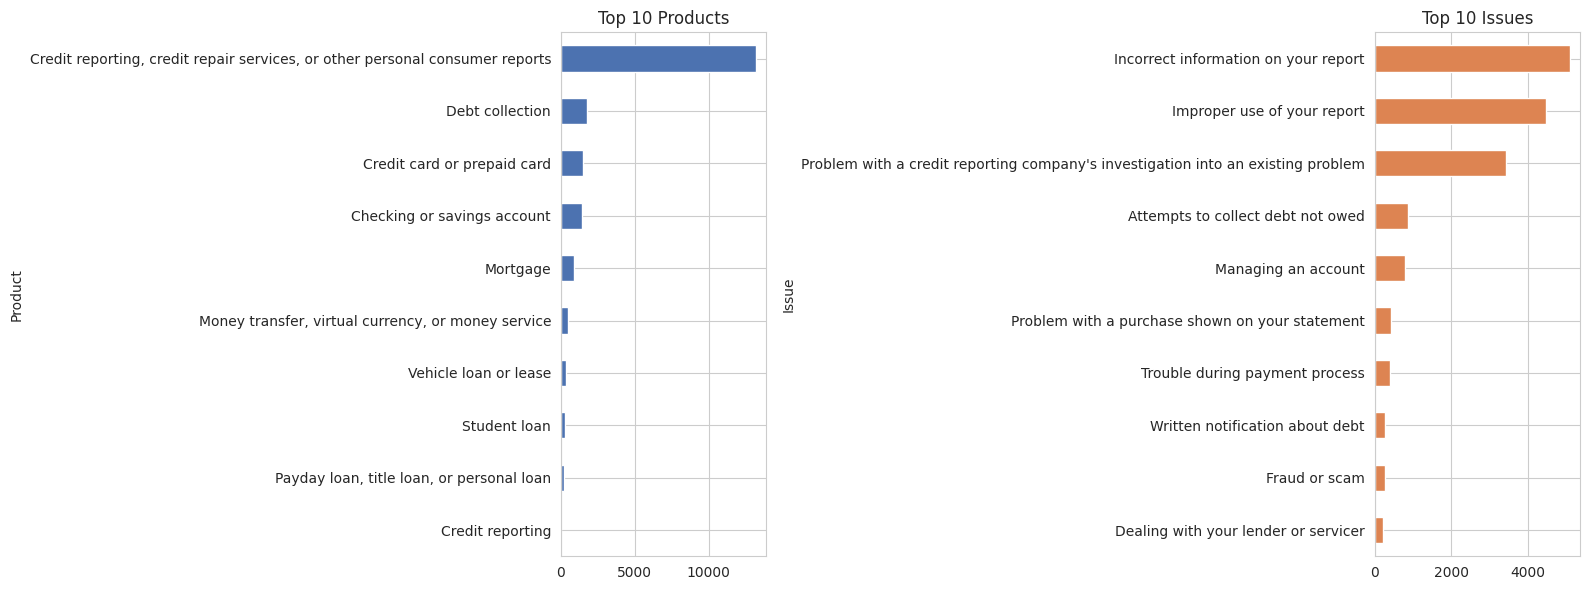

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df['Product'].value_counts().head(10).plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Top 10 Products')
axes[0].invert_yaxis()

df['Issue'].value_counts().head(10).plot(kind='barh', ax=axes[1], color='#DD8452')
axes[1].set_title('Top 10 Issues')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figures/top_products_issues.png", dpi=150)
plt.show()


### 3.3 Complaint volume over time

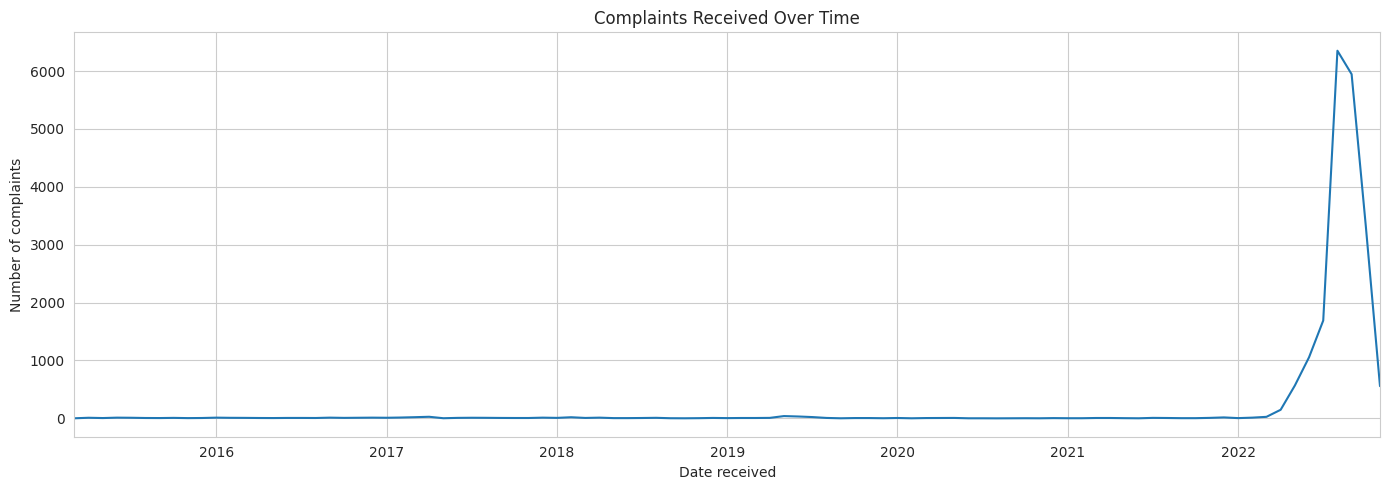

In [11]:
ts = df.set_index('Date received').resample('ME').size()
plt.figure(figsize=(14, 5))
ts.plot()
plt.title('Complaints Received Over Time')
plt.ylabel('Number of complaints')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figures/complaints_over_time.png", dpi=150)
plt.show()


### 3.4 Narrative length distribution

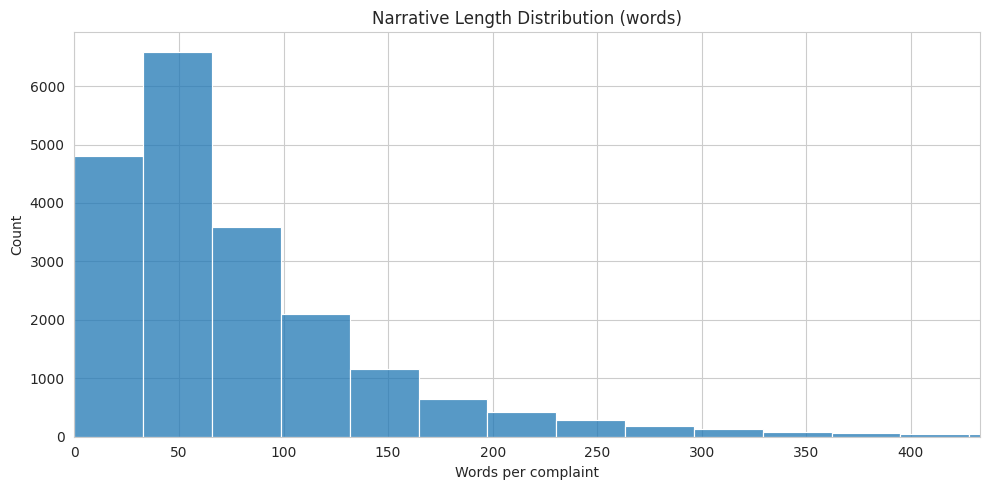

count    20296.000000
mean        82.935455
std         91.057527
min          0.000000
25%         33.750000
50%         57.000000
75%        101.000000
max       1975.000000
Name: narrative_len_words, dtype: float64


In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df['narrative_len_words'], bins=60)
plt.xlim(0, df['narrative_len_words'].quantile(0.99))
plt.title('Narrative Length Distribution (words)')
plt.xlabel('Words per complaint')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figures/narrative_length_dist.png", dpi=150)
plt.show()

print(df['narrative_len_words'].describe())


### 3.5 Response effectiveness

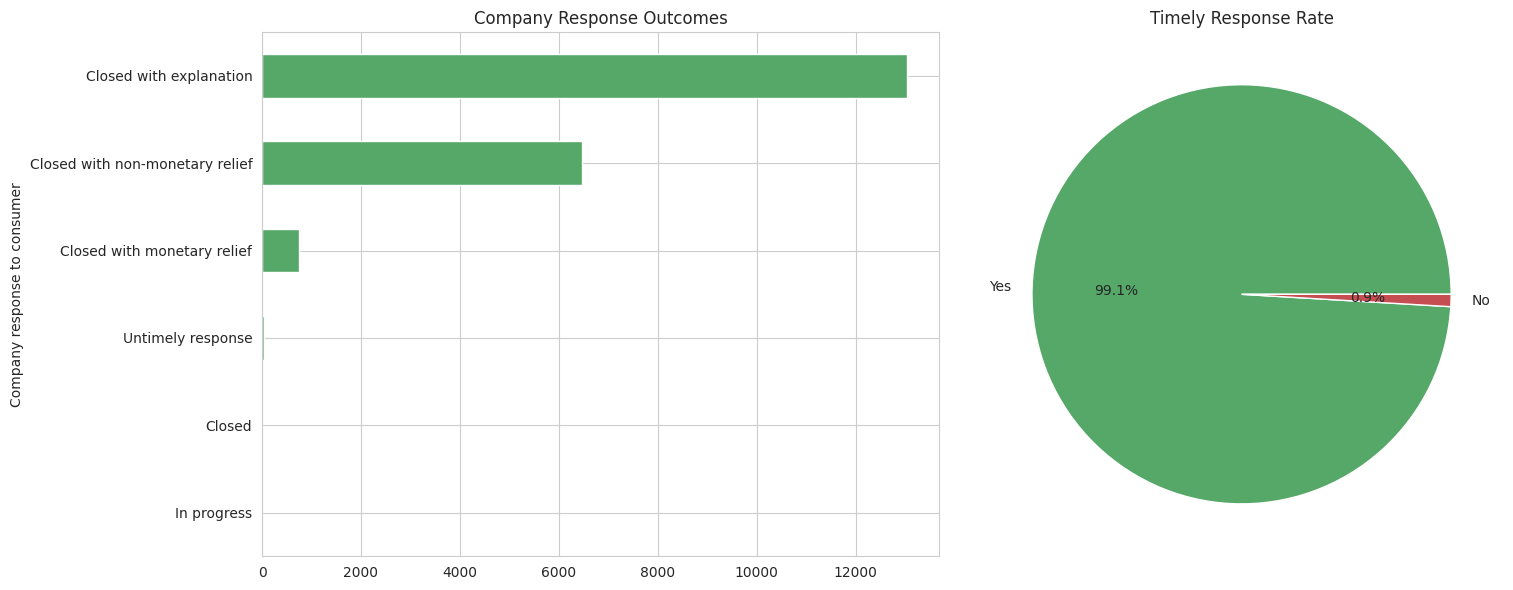

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df['Company response to consumer'].value_counts().plot(kind='barh', ax=axes[0], color='#55A868')
axes[0].set_title('Company Response Outcomes')
axes[0].invert_yaxis()

df['Timely response?'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['#55A868', '#C44E52']
)
axes[1].set_title('Timely Response Rate')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figures/response_effectiveness.png", dpi=150)
plt.show()


### 3.6 Most frequent terms (word frequency + word cloud)

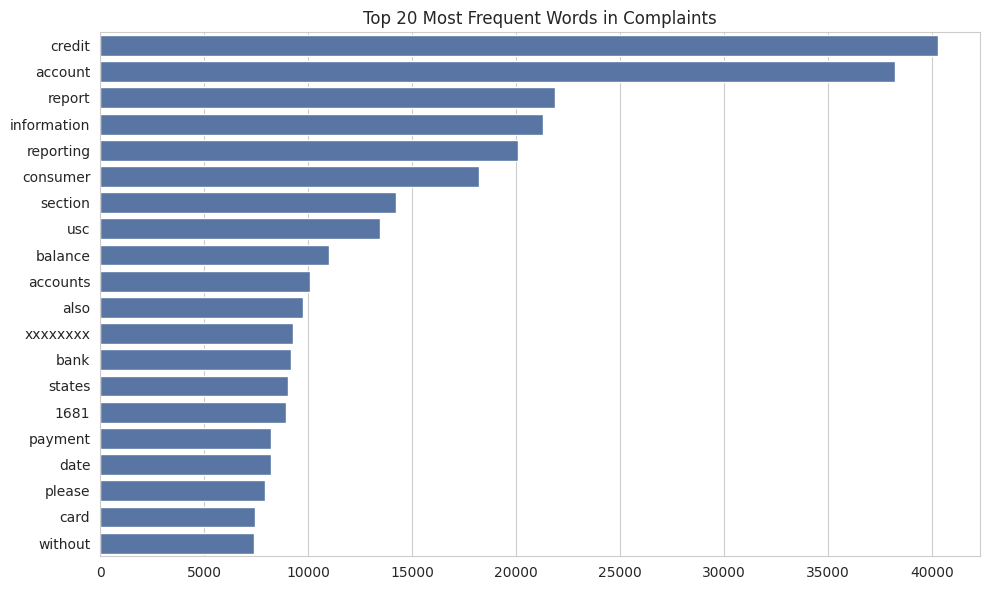

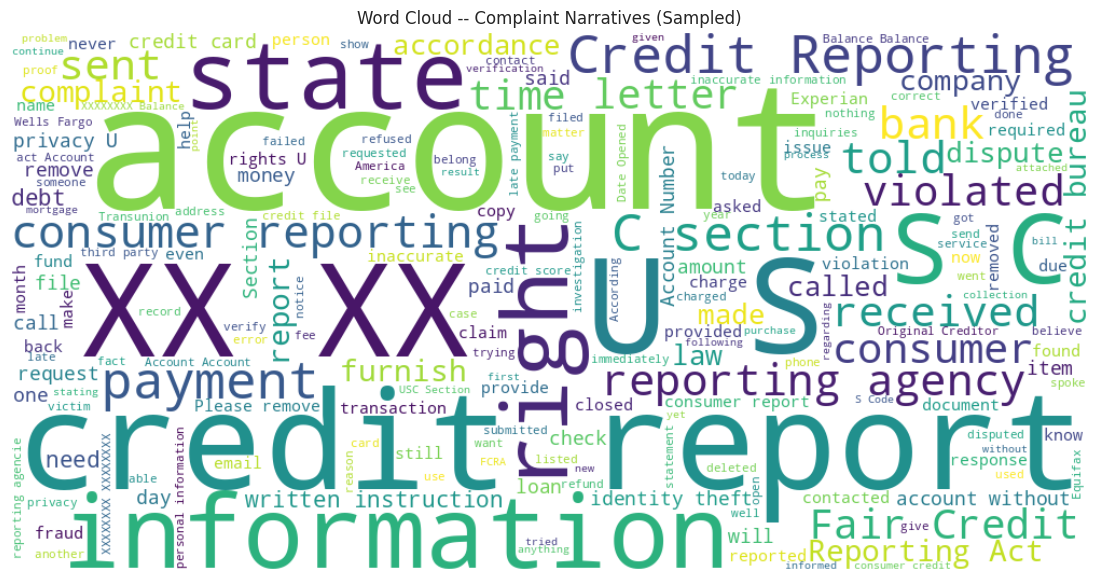

In [14]:
from wordcloud import WordCloud

# Top 20 words bar chart
all_tokens = [tok for toks in df['tokens'].sample(min(len(df), 100_000), random_state=42) for tok in toks]
top_words = Counter(all_tokens).most_common(20)
words, counts = zip(*top_words)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words), color='#4C72B0')
plt.title('Top 20 Most Frequent Words in Complaints')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figures/top_words.png", dpi=150)
plt.show()

# Word cloud (sampled for speed/memory)
sample_text = df['narrative_clean'].dropna().sample(n=min(len(df), 10000), random_state=42).astype(str)
wc = WordCloud(width=1000, height=500, background_color='white').generate(" ".join(sample_text))

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud -- Complaint Narratives (Sampled)')
plt.savefig(f"{OUTPUT_DIR}/figures/wordcloud.png", dpi=150)
plt.show()


### 3.7 Topic distribution (lightweight clustering)
Uses TF-IDF + KMeans on a sample (topic modeling on the full dataset is unnecessary for EDA insight and slow on Colab free tier).

Top terms per discovered topic cluster:

Topic 0 (4406 complaints): credit, report, account, information, accounts, reporting, inquiries, remove, experian, removed
Topic 1 (2428 complaints): section, 1681, states, 15, account, reporting, consumer, violated, rights, privacy
Topic 2 (6665 complaints): account, bank, 00, card, loan, payment, told, credit, money, called
Topic 3 (1647 complaints): consumer, 15, information, usc, reporting, 1681, report, credit, section, account
Topic 4 (1512 complaints): xx, 2022, credit, account, report, 22, 00, bank, xxxxxxxx, inquiry
Topic 5 (1039 complaints): debt, collection, company, credit, validation, account, alleged, report, collector, collect
Topic 6 (222 complaints): score, fico, low, attempting, causing, refused, consumers, record, transunion, credit
Topic 7 (2081 complaints): balance, 00, xxxxxxxx, complaint, credit, information, accounts, theft, report, date


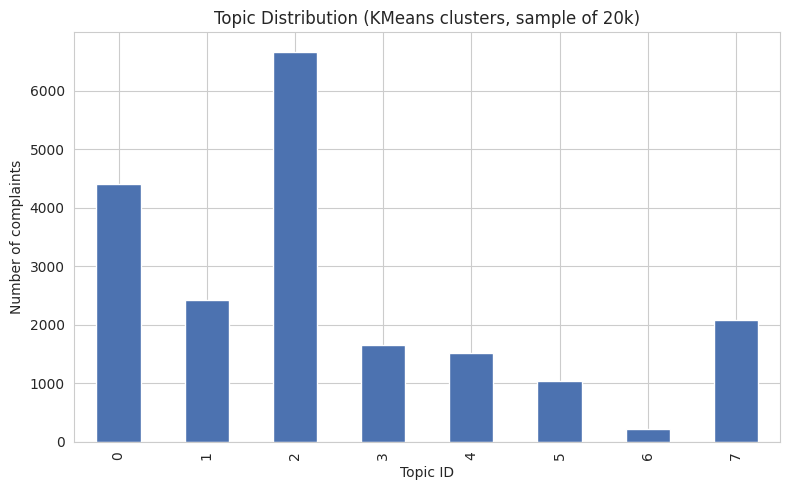

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

sample_df = df.sample(min(len(df), 20_000), random_state=42).copy()
min_df_safe = 5 if len(sample_df) >= 50 else 1

tfidf = TfidfVectorizer(max_features=5000, stop_words='english', min_df=min_df_safe)
X = tfidf.fit_transform(sample_df['narrative_clean'])

N_TOPICS = 8
km = KMeans(n_clusters=N_TOPICS, random_state=42, n_init=10)
sample_df['topic'] = km.fit_predict(X)

terms = tfidf.get_feature_names_out()
print("Top terms per discovered topic cluster:\n")
for i in range(N_TOPICS):
    center = km.cluster_centers_[i]
    top_idx = center.argsort()[-10:][::-1]
    print(f"Topic {i} ({(sample_df['topic']==i).sum()} complaints): " +
          ", ".join(terms[j] for j in top_idx))

plt.figure(figsize=(8, 5))
sample_df['topic'].value_counts().sort_index().plot(kind='bar', color='#4C72B0')
plt.title('Topic Distribution (KMeans clusters, sample of 20k)')
plt.xlabel('Topic ID')
plt.ylabel('Number of complaints')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figures/topic_distribution.png", dpi=150)
plt.show()


## 4. Save Deliverables

In [16]:
import pandas as pd

print("🔧 Generating missing text preprocessing columns...")

# 1. إنشاء عمود narrative_clean (تنظيف مبدئي وملء الفراغات)
df['narrative_clean'] = df['Consumer complaint narrative'].fillna("No narrative provided").astype(str)

# 2. إنشاء عمود narrative_len_words (حساب عدد الكلمات)
df['narrative_len_words'] = df['narrative_clean'].apply(lambda x: len(x.split()))

# 3. إنشاء عمود rag_document (أهم خطوة لشغل Person 2)
# دمج البيانات الوصفية مع النص عشان الـ Vector Search يفهم السياق
df['rag_document'] = (
    "Product: " + df['Product'].fillna("Unknown") + " | " +
    "Issue: " + df['Issue'].fillna("Unknown") + " | " +
    "Narrative: " + df['narrative_clean']
)

# 4. الحفظ والتصدير (Deliverable 1)
export_cols = ['Complaint ID', 'Date received', 'Product', 'Sub-product', 'Issue',
               'Sub-issue', 'Company', 'State', 'Company response to consumer',
               'Timely response?', 'narrative_clean', 'rag_document', 'narrative_len_words']
export_cols = ['Complaint ID', 'Date received', 'Product', 'Sub-product', 'Issue',
               'Sub-issue', 'Company', 'State', 'Company response to consumer',
               'Timely response?', 'narrative_clean', 'rag_document', 'narrative_len_words']

corpus_path = f"{OUTPUT_DIR}/processed_corpus.csv"
df[export_cols].to_csv(corpus_path, index=False)
print(f"\u2705 Saved processed corpus: {corpus_path} ({len(df):,} rows)")


🔧 Generating missing text preprocessing columns...
✅ Saved processed corpus: /content/drive/MyDrive/Project5_Outputs/processed_corpus.csv (20,296 rows)


In [17]:
before = len(df)
top_products = df['Product'].value_counts().head(5)
top_issues = df['Issue'].value_counts().head(5)
timely_rate = (df['Timely response?'] == 'Yes').mean() * 100
resolved_rate = df['Company response to consumer'].str.contains('Closed', na=False).mean() * 100

report = f"""# Support Data EDA Report
## Milestone 1 -- Customer Support RAG Chatbot

**Corpus size after cleaning:** {len(df):,} complaints
**Date range:** {df['Date received'].min().date()} to {df['Date received'].max().date()}

## Top 5 Products (query categories)
{top_products.to_string()}

## Top 5 Issues
{top_issues.to_string()}

## Response Effectiveness
- Timely response rate: {timely_rate:.1f}%
- Resolved / closed rate: {resolved_rate:.1f}%

## Narrative Length
- Mean: {df['narrative_len_words'].mean():.0f} words
- Median: {df['narrative_len_words'].median():.0f} words
- 95th percentile: {df['narrative_len_words'].quantile(0.95):.0f} words

## Topic Distribution
{N_TOPICS} topic clusters discovered via TF-IDF + KMeans on a 20k sample
(see figures/topic_distribution.png and the printed top-terms-per-topic output above).

## Figures
See `figures/` folder: top_products_issues.png, complaints_over_time.png,
narrative_length_dist.png, response_effectiveness.png, top_words.png,
wordcloud.png, topic_distribution.png
"""

with open(f"{OUTPUT_DIR}/eda_report.md", "w") as f:
    f.write(report)

print(report)
print(f"\n\u2705 EDA report saved to: {OUTPUT_DIR}/eda_report.md")


# Support Data EDA Report
## Milestone 1 -- Customer Support RAG Chatbot

**Corpus size after cleaning:** 20,296 complaints
**Date range:** 2015-03-28 to 2022-11-09

## Top 5 Products (query categories)
Product
Credit reporting, credit repair services, or other personal consumer reports    13247
Debt collection                                                                  1778
Credit card or prepaid card                                                      1533
Checking or savings account                                                      1404
Mortgage                                                                          872

## Top 5 Issues
Issue
Incorrect information on your report                                                5106
Improper use of your report                                                         4484
Problem with a credit reporting company's investigation into an existing problem    3443
Attempts to collect debt not owed                                    

---
✅ **Milestone 1 complete.** Deliverables saved to `OUTPUT_DIR`:
- `processed_corpus.csv` — cleaned, deduplicated corpus with unified `rag_document` field
- `eda_report.md` — EDA report
- `figures/` — all charts

---

# 🤖 Milestone 2 — RAG Pipeline

In [18]:
!pip install -q langchain-chroma langchain-community langchain-core langchain-text-splitters \
    sentence-transformers chromadb google-genai rouge-score

import gc
import time
from langchain_chroma import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_core.documents import Document
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_text_splitters import RecursiveCharacterTextSplitter
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from google import genai
from google.colab import userdata


/tmp/ipykernel_71465/3103746428.py:6: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.embeddings import HuggingFaceEmbeddings


## 1. Vector Store — Full Dataset, Memory-Safe Batching

Builds the Chroma vector store from the **entire** cleaned corpus (not a `head(5000)` sample), in fixed-size batches, freeing memory between batches so Colab RAM stays under control.

In [19]:
import gc
from langchain_core.documents import Document
from langchain_chroma import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings

# ==========================
# CONFIG
# ==========================
MAX_ROWS = 5000        # None = Full Dataset
BATCH_SIZE = 1000

# ==========================
# Prepare Data
# ==========================
df_processed = df.dropna(subset=["rag_document"]).copy()

if MAX_ROWS is not None:
    df_processed = df_processed.head(MAX_ROWS)

print(f"Preparing {len(df_processed):,} documents...")

# ==========================
# Embedding Model
# ==========================
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vector_store = None

# ==========================
# Batch Embedding
# ==========================
for i in range(0, len(df_processed), BATCH_SIZE):

    batch = df_processed.iloc[i:i+BATCH_SIZE]

    docs = [
        Document(
            page_content=row["rag_document"],
            metadata={
                "complaint_id": str(row["Complaint ID"]),
                "company": str(row["Company"])
            }
        )
        for _, row in batch.iterrows()
    ]

    if vector_store is None:

        vector_store = Chroma.from_documents(
            documents=docs,
            embedding=embeddings,
            persist_directory="./chromadb_index"
        )

    else:

        vector_store.add_documents(docs)

    print(f"Batch {(i//BATCH_SIZE)+1} finished")

    del docs
    gc.collect()

print("✅ Vector Store Created Successfully!")

# ==========================
# Sample Documents
# ==========================
documents_sample = [
    Document(
        page_content=row["rag_document"],
        metadata={
            "complaint_id": str(row["Complaint ID"]),
            "company": str(row["Company"])
        }
    )
    for _, row in df_processed.head(5000).iterrows()
]

print(f"Sample Size: {len(documents_sample)}")

Preparing 5,000 documents...


/tmp/ipykernel_71465/3105506783.py:25: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batch 1 finished
Batch 2 finished
Batch 3 finished
Batch 4 finished
Batch 5 finished
✅ Vector Store Created Successfully!
Sample Size: 5000


## 2. RAG Chain (Gemini)

In [20]:
try:
    GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
    os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
except Exception:
    print("\u274C Error: 'GOOGLE_API_KEY' not found in Colab Secrets. Add it from the left menu.")

client = genai.Client(api_key=GOOGLE_API_KEY)

retriever = vector_store.as_retriever(search_kwargs={"k": 3})

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

def direct_gemini_call(input_dict):
    context = input_dict["context"]
    question = input_dict["question"]
    full_prompt = (
        f"You are an expert customer support AI assistant specializing in analyzing consumer financial complaints.\n"
        f"Use the provided pieces of retrieved context to answer the user's question accurately.\n"
        f"If you cannot find the answer in the context, clearly state that you do not know.\n\n"
        f"Context:\n{context}\n\nQuestion: {question}\nAnswer:"
    )
    try:
        response = client.models.generate_content(model='gemini-2.5-flash', contents=full_prompt)
        return response.text
    except Exception as e:
        return f"Error calling Gemini: {str(e)}"

rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | RunnableLambda(direct_gemini_call)
)

print("\U0001F680 RAG chain initialized. Ready for evaluation.")


🚀 RAG chain initialized. Ready for evaluation.


## 3. Test Queries — Generate Answers

In [21]:
test_queries = [
    "I have an issue with U.S. BANCORP regarding my mother's closed credit card account which had a credit balance of $420.00, and I have power of attorney. What happened in this specific complaint?",
    "What are the details of the complaint filed against I.C. System, Inc. regarding an attempt to collect a debt not owed due to identity theft hindering the consumer's ability to close a loan?",
    "Search the data for a mortgage-related issue involving Shellpoint Partners, LLC where the servicing remained with Newrez LLC. What was the core problem?",
    "If a consumer complains that Wells Fargo is incorrectly reporting a checking/savings account as a credit card on their credit profile, what is the typical company response or resolution outcome for such an issue?",
    "Based on the dataset, when consumers file complaints against credit reporting agencies like TransUnion for 'Improper use of your report', what legal sections or standard explanations do companies usually provide in their response?",
    "Summarize the primary reasons why consumers file complaints regarding 'Attempts to collect debt not owed' within this dataset sample. What is the most common underlying cause?",
    "What are the main arguments consumers use when accusing credit reporting companies (like Equifax or TransUnion) of violating their privacy rights under 15 U.S.C. 1681 Section 602?",
    "I went through my credit records and noticed fraudulent accounts that do not belong to me are still reposting on my file even after I disputed them. What insights or patterns do similar complaints in the database show regarding this situation?",
    "Are there any complaints in the dataset where credit bureaus or companies refuse to process disputes because they suspect it was filed by a third-party or a credit repair company rather than the consumer themselves?"
]

print("\U0001F504 Running RAG pipeline over test queries...")
eval_results = []
for i, query in enumerate(test_queries, 1):
    print(f"\U0001F914 Answering Question {i}/{len(test_queries)}...")
    try:
        answer = rag_chain.invoke(query)
    except Exception as e:
        answer = f"Error generating answer: {str(e)}"
    eval_results.append({"question_number": i, "question": query, "bot_answer": answer})

with open("./evaluation_report.txt", "w", encoding="utf-8") as f:
    f.write("=" * 50 + "\n          RAG CHATBOT EVALUATION REPORT          \n" + "=" * 50 + "\n\n")
    for res in eval_results:
        f.write(f"### Q{res['question_number']}: {res['question']}\n")
        f.write(f"\U0001F916 Bot Answer:\n{res['bot_answer']}\n")
        f.write("-" * 50 + "\n\n")

print("\n\U0001F389 Evaluation complete! Report saved to evaluation_report.txt")


🔄 Running RAG pipeline over test queries...
🤔 Answering Question 1/9...
🤔 Answering Question 2/9...
🤔 Answering Question 3/9...
🤔 Answering Question 4/9...
🤔 Answering Question 5/9...
🤔 Answering Question 6/9...
🤔 Answering Question 7/9...
🤔 Answering Question 8/9...
🤔 Answering Question 9/9...

🎉 Evaluation complete! Report saved to evaluation_report.txt


## 4. Evaluation — Generation Quality (BLEU / ROUGE)

In [23]:
eval_dataset = [
    {"question": "What are the details of the complaint filed against I.C. System, Inc. regarding an attempt to collect a debt not owed due to identity theft hindering the consumer's ability to close a loan?",
     "ground_truth": "I.C. System, Inc. attempted to collect a debt that the consumer did not owe because it resulted from identity theft. This fraudulent debt severely hindered the consumer's ability to secure or close a loan."},
    {"question": "If a consumer complains that Wells Fargo is incorrectly reporting a checking/savings account as a credit card on their credit profile, what is the typical company response or resolution outcome for such an issue?",
     "ground_truth": "Wells Fargo typically responds by reviewing the credit profile reporting error, updating the status, and confirming whether the account is correctly categorized as a banking relationship or closing/correcting the record."},
    {"question": "Summarize the primary reasons why consumers file complaints regarding 'Attempts to collect debt not owed' within this dataset sample. What is the most common underlying cause?",
     "ground_truth": "The primary reasons include identity theft, medical bills already paid, or misidentified accounts. The most common underlying cause is outdated or incorrect information in collection agency records."}
]

scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
smoothing = SmoothingFunction().method1

def calculate_metrics(bot_ans, ground_truth):
    rouge_results = scorer.score(ground_truth, bot_ans)
    r1, rl = rouge_results['rouge1'].fmeasure, rouge_results['rougeL'].fmeasure
    bleu = sentence_bleu([ground_truth.lower().split()], bot_ans.lower().split(),
                          weights=(0.5, 0.5, 0, 0), smoothing_function=smoothing)
    return round(r1, 3), round(rl, 3), round(bleu, 3)

results_list = []
for idx, item in enumerate(eval_dataset, 1):
    q, gt = item["question"], item["ground_truth"]
    start_time = time.time()

    docs = retriever.invoke(q)
    context = "\n\n".join(doc.page_content for doc in docs)
    full_prompt = f"Context:\n{context}\n\nQuestion: {q}\nAnswer:"

    response = client.models.generate_content(model='gemini-2.5-flash', contents=full_prompt)
    latency = round(time.time() - start_time, 2)
    r1, rl, bleu = calculate_metrics(response.text, gt)

    results_list.append({"Q": idx, "Latency(s)": latency, "ROUGE-1": r1, "ROUGE-L": rl, "BLEU": bleu})

df_metrics = pd.DataFrame(results_list)
print(df_metrics.to_markdown(index=False))
df_metrics.to_csv("metrics_report.csv", index=False)


|   Q |   Latency(s) |   ROUGE-1 |   ROUGE-L |   BLEU |
|----:|-------------:|----------:|----------:|-------:|
|   1 |        11.31 |     0.195 |     0.169 |  0.065 |
|   2 |        12.59 |     0.071 |     0.06  |  0.016 |
|   3 |         4.39 |     0.257 |     0.218 |  0.109 |


## 5. Evaluation — Retrieval Quality (Recall@K, MRR)

BLEU/ROUGE only score the *generated answer text*. Recall@K and MRR score whether the **retriever** found the right complaints in the first place.

**Ground-truth note:** the 9 `test_queries` were written by describing a specific real complaint (a company + a distinctive issue). Since no manually labeled "relevant complaint_id" list exists, ground truth is derived programmatically from each query's company/issue signature and matched against `Complaint ID`s actually in the vector store.

In [24]:
retrieval_ground_truth = [
    {"company_contains": "U.S. BANCORP"},
    {"company_contains": "I.C. SYSTEM"},
    {"company_contains": "SHELLPOINT"},
    {"company_contains": "WELLS FARGO", "issue_contains": "credit card"},
    {"company_contains": "TRANSUNION", "issue_contains": "improper use"},
    {"issue_contains": "attempts to collect debt not owed"},
    {"company_contains": "EQUIFAX|TRANSUNION", "issue_contains": "privacy"},
    {"issue_contains": "fraud", "narrative_contains": "dispute"},
    {"issue_contains": "dispute", "narrative_contains": "third party|credit repair"},
]

def get_relevant_ids(df_source, filt):
    """Return the set of Complaint IDs in df_source matching a relevance filter."""
    mask = pd.Series(True, index=df_source.index)
    if "company_contains" in filt:
        mask &= df_source['Company'].astype(str).str.contains(filt["company_contains"], case=False, na=False, regex=True)
    if "issue_contains" in filt:
        mask &= df_source['Issue'].astype(str).str.contains(filt["issue_contains"], case=False, na=False, regex=True)
    if "narrative_contains" in filt:
        mask &= df_source['narrative_clean'].astype(str).str.contains(filt["narrative_contains"], case=False, na=False, regex=True)
    return set(df_source.loc[mask, 'Complaint ID'].astype(str))

ground_truth_ids = [get_relevant_ids(df_processed, f) for f in retrieval_ground_truth]
for i, ids in enumerate(ground_truth_ids, 1):
    print(f"Q{i}: {len(ids)} relevant complaint(s) found in the embedded corpus")

def evaluate_retrieval(retriever, queries, ground_truth_ids, k=5):
    """Recall@K: fraction of known-relevant docs found in top-K. MRR: mean reciprocal rank of first hit."""
    recalls, reciprocal_ranks = [], []
    for query, rel_ids in zip(queries, ground_truth_ids):
        if not rel_ids:
            continue
        docs = retriever.invoke(query)
        retrieved_ids = [d.metadata.get("complaint_id") for d in docs[:k]]
        hits = [1 if rid in rel_ids else 0 for rid in retrieved_ids]
        recalls.append(sum(hits) / min(len(rel_ids), k))
        rr = 0.0
        for rank, is_hit in enumerate(hits, 1):
            if is_hit:
                rr = 1 / rank
                break
        reciprocal_ranks.append(rr)
    return {
        "k": k,
        "num_queries_evaluated": len(recalls),
        "Recall@K": round(sum(recalls) / len(recalls), 3) if recalls else 0.0,
        "MRR": round(sum(reciprocal_ranks) / len(reciprocal_ranks), 3) if reciprocal_ranks else 0.0,
    }

retrieval_report_rows = [evaluate_retrieval(retriever, test_queries, ground_truth_ids, k=k) for k in [1, 3, 5]]
retrieval_report_df = pd.DataFrame(retrieval_report_rows)
print("\n--- Retrieval Evaluation Report (also compares k=1 vs k=3 vs k=5) ---")
print(retrieval_report_df.to_markdown(index=False))
retrieval_report_df.to_csv("retrieval_evaluation_report.csv", index=False)


Q1: 68 relevant complaint(s) found in the embedded corpus
Q2: 34 relevant complaint(s) found in the embedded corpus
Q3: 27 relevant complaint(s) found in the embedded corpus
Q4: 3 relevant complaint(s) found in the embedded corpus
Q5: 408 relevant complaint(s) found in the embedded corpus
Q6: 221 relevant complaint(s) found in the embedded corpus
Q7: 0 relevant complaint(s) found in the embedded corpus
Q8: 6 relevant complaint(s) found in the embedded corpus
Q9: 0 relevant complaint(s) found in the embedded corpus

--- Retrieval Evaluation Report (also compares k=1 vs k=3 vs k=5) ---
|   k |   num_queries_evaluated |   Recall@K |   MRR |
|----:|------------------------:|-----------:|------:|
|   1 |                       7 |      0.571 | 0.571 |
|   3 |                       7 |      0.571 | 0.643 |
|   5 |                       7 |      0.343 | 0.643 |


## 6. Optimization Experiments

Beyond the k-comparison already produced above, this section compares:
- **Prompt engineering** — baseline prompt vs a role/constraint-based prompt
- **Embedding model** — `all-MiniLM-L6-v2` (current) vs `all-mpnet-base-v2` (larger, usually higher quality)
- **Chunk size / overlap** — splitting `rag_document` into smaller chunks at two sizes, vs one chunk per complaint
- **Retrieval strategy** — similarity search vs MMR (Maximal Marginal Relevance)

All experiments are scored with the same `evaluate_retrieval()` / `calculate_metrics()` functions defined above, for a like-for-like comparison.

### 6.1 Prompt Engineering Comparison

In [25]:
def get_prompt(context, question, version="v1"):
    if version == "v1":
        return f"Context:\n{context}\n\nQuestion: {question}\nAnswer:"
    return (
        f"You are a professional Financial Complaint Analyst. "
        f"Use ONLY the provided context below to answer. "
        f"If the answer isn't in the context, say 'I do not have enough information.' "
        f"Do not invent facts.\n\nContext:\n{context}\n\nQuestion: {question}\nAnswer:"
    )

def run_comparison(eval_dataset, version):
    results = []
    for item in eval_dataset:
        docs = retriever.invoke(item["question"])
        context = "\n\n".join(doc.page_content for doc in docs)
        full_prompt = get_prompt(context, item["question"], version)
        response = client.models.generate_content(model='gemini-2.5-flash', contents=full_prompt)
        r1, rl, bleu = calculate_metrics(response.text, item["ground_truth"])
        results.append({"Version": version, "Question": item["question"][:40] + "...",
                         "ROUGE-1": r1, "ROUGE-L": rl, "BLEU": bleu})
    return pd.DataFrame(results)

df_v1 = run_comparison(eval_dataset, "v1")
df_v2 = run_comparison(eval_dataset, "v2")
comparison_df = pd.concat([df_v1, df_v2])
print(comparison_df.to_markdown(index=False))
comparison_df.to_csv("prompt_comparison_report.csv", index=False)


| Version   | Question                                    |   ROUGE-1 |   ROUGE-L |   BLEU |
|:----------|:--------------------------------------------|----------:|----------:|-------:|
| v1        | What are the details of the complaint fi... |     0.221 |     0.206 |  0.076 |
| v1        | If a consumer complains that Wells Fargo... |     0.09  |     0.064 |  0.019 |
| v1        | Summarize the primary reasons why consum... |     0.272 |     0.214 |  0.111 |
| v2        | What are the details of the complaint fi... |     0.235 |     0.196 |  0.08  |
| v2        | If a consumer complains that Wells Fargo... |     0     |     0     |  0     |
| v2        | Summarize the primary reasons why consum... |     0.208 |     0.13  |  0.086 |


### 6.2 Embedding Model Comparison

In [33]:
from uuid import uuid4
def build_temp_retriever(docs, embedding_model, search_type="similarity", k=5):
    emb = HuggingFaceEmbeddings(model_name=embedding_model)

    store = Chroma.from_documents(
        documents=docs,
        embedding=emb,
        collection_name=f"temp_{uuid4().hex}"   # Collection جديدة كل مرة
    )

    return store.as_retriever(
        search_type=search_type,
        search_kwargs={"k": k}
    )
# ---------------------------------------------------
# Use a small sample for optimization experiments
# ---------------------------------------------------
documents_sample = documents_sample[:500]

embedding_models = [
    "all-MiniLM-L6-v2",
    "all-mpnet-base-v2"
]

embedding_results = []

for model_name in embedding_models:
    print(f"\n🔄 Testing {model_name}...")

    temp_retriever = build_temp_retriever(
        docs=documents_sample,
        embedding_model=model_name,
        k=5
    )

    metrics = evaluate_retrieval(
        temp_retriever,
        test_queries,
        ground_truth_ids,
        k=5
    )

    metrics["Embedding Model"] = model_name
    embedding_results.append(metrics)

    print(f"✅ Finished {model_name}")

embedding_results_df = pd.DataFrame(embedding_results)

display(embedding_results_df)


🔄 Testing all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✅ Finished all-MiniLM-L6-v2

🔄 Testing all-mpnet-base-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Finished all-mpnet-base-v2


,k,num_queries_evaluated,Recall@K,MRR,Embedding Model
0,5,7,0.200,0.643,all-MiniLM-L6-v2
1,5,7,0.343,0.643,all-mpnet-base-v2


### 6.3 Chunk Size / Overlap Comparison

In [34]:
chunk_configs = [
    {"chunk_size": 300, "chunk_overlap": 30},
    {"chunk_size": 600, "chunk_overlap": 100},
]
chunk_results = []
for cfg in chunk_configs:
    splitter = RecursiveCharacterTextSplitter(chunk_size=cfg["chunk_size"], chunk_overlap=cfg["chunk_overlap"])
    chunked_docs = splitter.split_documents(documents_sample)
    print(f"\U0001F504 chunk_size={cfg['chunk_size']}, overlap={cfg['chunk_overlap']} "
          f"({len(chunked_docs)} chunks from {len(documents_sample)} documents)")
    temp_retriever = build_temp_retriever(chunked_docs, "all-MiniLM-L6-v2", k=5)
    res = evaluate_retrieval(temp_retriever, test_queries, ground_truth_ids, k=5)
    res.update(cfg)
    chunk_results.append(res)

chunk_results_df = pd.DataFrame(chunk_results)
print(chunk_results_df.to_markdown(index=False))


🔄 chunk_size=300, overlap=30 (2659 chunks from 500 documents)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

🔄 chunk_size=600, overlap=100 (1477 chunks from 500 documents)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

|   k |   num_queries_evaluated |   Recall@K |   MRR |   chunk_size |   chunk_overlap |
|----:|------------------------:|-----------:|------:|-------------:|----------------:|
|   5 |                       7 |      0.343 | 0.571 |          300 |              30 |
|   5 |                       7 |      0.314 | 0.643 |          600 |             100 |


### 6.4 Retrieval Strategy — Similarity vs MMR

In [36]:
strategy_results = []
for strategy in ["similarity", "mmr"]:
    print(f"\U0001F504 Testing retrieval strategy: {strategy}")
    strat_retriever = vector_store.as_retriever(search_type=strategy, search_kwargs={"k": 5})
    res = evaluate_retrieval(strat_retriever, test_queries, ground_truth_ids, k=5)
    res["strategy"] = strategy
    strategy_results.append(res)

strategy_results_df = pd.DataFrame(strategy_results)
print(strategy_results_df.to_markdown(index=False))

with open("optimization_experiments_report.md", "w", encoding="utf-8") as f:
    f.write("# Milestone 2 -- Optimization Experiments\n\n")
    f.write("## Retriever k Comparison\n\n" + retrieval_report_df.to_markdown(index=False) + "\n\n")
    f.write("## Prompt Engineering Comparison\n\n" + comparison_df.to_markdown(index=False) + "\n\n")
    f.write("## Embedding Model Comparison\n\n" + embedding_results_df.to_markdown(index=False) + "\n\n")
    f.write("## Chunk Size / Overlap Comparison\n\n" + chunk_results_df.to_markdown(index=False) + "\n\n")
    f.write("## Retrieval Strategy Comparison\n\n" + strategy_results_df.to_markdown(index=False) + "\n")

print("\n\u2705 All optimization experiments complete. Report saved to optimization_experiments_report.md")


🔄 Testing retrieval strategy: similarity
🔄 Testing retrieval strategy: mmr
|   k |   num_queries_evaluated |   Recall@K |   MRR | strategy   |
|----:|------------------------:|-----------:|------:|:-----------|
|   5 |                       7 |      0.543 | 0.643 | similarity |
|   5 |                       7 |      0.429 | 0.643 | mmr        |

✅ All optimization experiments complete. Report saved to optimization_experiments_report.md


## 7. Final Reports Summary

All Milestone 2 deliverables generated by this notebook:
- `evaluation_report.txt` — RAG answers to the 9 test queries
- `metrics_report.csv` — BLEU / ROUGE generation-quality scores
- `retrieval_evaluation_report.csv` — Recall@K and MRR retrieval-quality scores (k=1,3,5)
- `prompt_comparison_report.csv` — prompt engineering comparison
- `optimization_experiments_report.md` — combined optimization report (k, prompt, embedding model, chunk size, retrieval strategy)

---
✅ **Milestone 2 complete.**

---

# 🎁 Bonus (Optional) — Streamlit Deployment Preview

Not required for Milestone 1/2 grading — included as an extra deliverable showing the chatbot deployed as an interactive app. Requires `GOOGLE_API_KEY` as an environment variable and a tunneling tool (e.g. `localtunnel`) in Colab.

In [37]:
%%writefile app.py
import streamlit as st
import os
from langchain_chroma import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from google import genai

st.set_page_config(page_title="Complaints Analytics RAG", page_icon="\U0001F916", layout="centered")
st.title("\U0001F916 Consumer Complaints RAG Chatbot")
st.write("Ask questions about companies, financial products, or specific consumer disputes.")

GOOGLE_API_KEY = os.environ.get("GOOGLE_API_KEY")

@st.cache_resource
def init_resources():
    embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
    vector_store = Chroma(persist_directory="./chromadb_index", embedding_function=embeddings)
    retriever = vector_store.as_retriever(search_kwargs={"k": 3})
    client = genai.Client(api_key=GOOGLE_API_KEY)
    return retriever, client

try:
    retriever, client = init_resources()
    st.success("RAG System Active & Database Connected!")
except Exception as e:
    st.error(f"Initialization Error: {e}")

if "messages" not in st.session_state:
    st.session_state.messages = []

for message in st.session_state.messages:
    with st.chat_message(message["role"]):
        st.markdown(message["content"])

if user_query := st.chat_input("Type your question here..."):
    with st.chat_message("user"):
        st.markdown(user_query)
    st.session_state.messages.append({"role": "user", "content": user_query})

    with st.chat_message("assistant"):
        with st.spinner("Searching database & generating answer..."):
            docs = retriever.invoke(user_query)
            context = "\n\n".join(doc.page_content for doc in docs)
            full_prompt = (
                f"You are an expert customer support AI assistant specializing in analyzing consumer financial complaints.\n"
                f"Use the provided pieces of retrieved context to answer the user's question accurately.\n"
                f"If you cannot find the answer in the context, clearly state that you do not know.\n\n"
                f"Context:\n{context}\n\nQuestion: {user_query}\nAnswer:"
            )
            try:
                response = client.models.generate_content(model='gemini-2.5-flash', contents=full_prompt)
                answer = response.text
            except Exception as e:
                answer = f"Error generating response: {e}"
            st.markdown(answer)

    st.session_state.messages.append({"role": "assistant", "content": answer})


Writing app.py


In [38]:
# Run the Streamlit app and expose it via a tunnel (optional -- run manually when needed)
# !streamlit run app.py & npx localtunnel --port 8501
